In [ ]:
import pandas as pd
import numpy as np

In [ ]:
reviews = pd.read_csv("movie_reviews.csv",index_col=0)
reviews.head()

,review_text,sentiment,rating
review_id,,,
1,This movie was absolutely fantastic! The actin...,1,9.0
2,Waste of time. Boring and predictable. I would...,0,2.0
3,A beautiful story with great performances. One...,1,8.5
4,Terrible script and weak direction. Could not ...,0,1.5
5,Loved every minute! The cinematography was stu...,1,9.5


In [ ]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 1 to 100
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   review_text  100 non-null    object 
 1   sentiment    100 non-null    int64  
 2   rating       100 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 3.1+ KB


In [ ]:
reviews.duplicated().sum()

np.int64(0)

In [ ]:
import re

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)  # remove HTML
    text = text.lower()               # lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # remove special chars
    text = text.strip()
    return text

reviews['clean_review_text'] = reviews['review_text'].apply(clean_text)
reviews.head()

,review_text,sentiment,rating,clean_review_text
review_id,,,,
1,This movie was absolutely fantastic! The actin...,1,9.0,this movie was absolutely fantastic the actin...
2,Waste of time. Boring and predictable. I would...,0,2.0,waste of time boring and predictable i would...
3,A beautiful story with great performances. One...,1,8.5,a beautiful story with great performances one...
4,Terrible script and weak direction. Could not ...,0,1.5,terrible script and weak direction could not ...
5,Loved every minute! The cinematography was stu...,1,9.5,loved every minute the cinematography was stu...


In [ ]:
from sklearn.model_selection import train_test_split

x = reviews['clean_review_text']
y = reviews['sentiment']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2,random_state=42)

In [ ]:
x_train

,clean_review_text
review_id,
56,complete waste of time and money avoid at all...
89,beautiful and inspiring exactly what i needed
27,inspiring and uplifting exactly what i needed...
43,fun and entertaining from start to finish gre...
70,forgettable and bland nothing stood out
...,...
61,powerful performances across the board a must...
72,poor character development could not care abo...
15,captivating from the first scene a must watch...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features = 5000)

x_train_tfid = vectorizer.fit_transform(x_train)
x_test_tfid = vectorizer.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train_tfid,y_train)

y_prd = model.predict(x_test_tfid)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_prd))
print(classification_report(y_test, y_prd))

Accuracy: 0.9
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         8
           1       1.00      0.83      0.91        12

    accuracy                           0.90        20
   macro avg       0.90      0.92      0.90        20
weighted avg       0.92      0.90      0.90        20



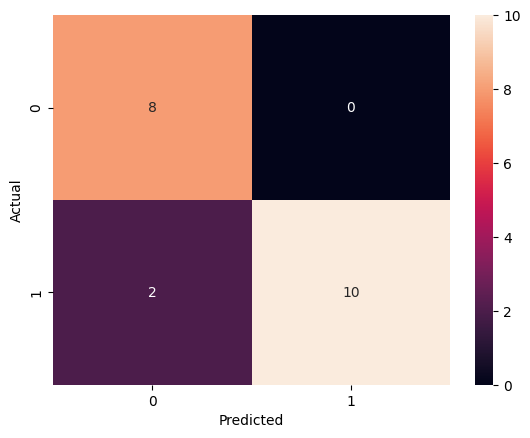

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_prd)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(x_train)

In [ ]:
x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)

In [ ]:
x_train_pad = pad_sequences(x_train_seq, maxlen=200)
x_test_pad = pad_sequences(x_test_seq, maxlen=200)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=100),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=['accuracy'])

In [ ]:
history = model.fit(x_train_pad,y_train,epochs=15,batch_size=32,validation_split=0.2)

Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 996ms/step - accuracy: 0.5625 - loss: 0.6927 - val_accuracy: 0.4375 - val_loss: 0.6920
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 387ms/step - accuracy: 0.6406 - loss: 0.6887 - val_accuracy: 0.4375 - val_loss: 0.6920
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step - accuracy: 0.6094 - loss: 0.6840 - val_accuracy: 0.4375 - val_loss: 0.6916
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 288ms/step - accuracy: 0.5781 - loss: 0.6771 - val_accuracy: 0.4375 - val_loss: 0.6894
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 326ms/step - accuracy: 0.5781 - loss: 0.6699 - val_accuracy: 0.4375 - val_loss: 0.6879
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 320ms/step - accuracy: 0.5469 - loss: 0.6603 - val_accuracy: 0.4375 - val_loss: 0.6846
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step - accuracy: 0.5781 - loss: 0.6423 - val_accuracy: 0.4375 - val_loss: 0.6803
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 305ms/step - accuracy: 0.5938 - loss: 0.6340 - val_accuracy: 0.5000 - val_loss:

In [ ]:
model.evaluate(x_test_pad,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8000 - loss: 0.5386


[0.5386283993721008, 0.800000011920929]

In [ ]:
y_pred = model.predict(x_test_pad)
y_pred_classes = (y_pred > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_classes))
print(classification_report(y_test, y_pred_classes))

Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         8
           1       1.00      0.67      0.80        12

    accuracy                           0.80        20
   macro avg       0.83      0.83      0.80        20
weighted avg       0.87      0.80      0.80        20



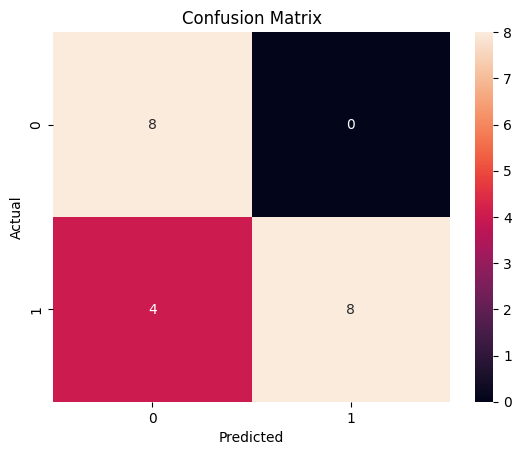

In [ ]:
cm = confusion_matrix(y_test, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

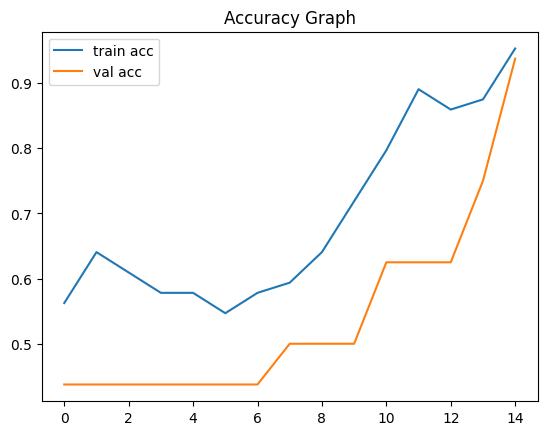

In [ ]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

In [ ]:
print(x_test.iloc[8])
print(y_test.iloc[8])
print(y_pred_classes[8][0])

heartwarming and funny  perfect for a weekend watch with family
1
1


In [ ]:
y_test = np.array(y_test)
incorrect_indices = np.where(y_prd != y_test)[0]

for i in incorrect_indices[:5]:
    print("Review:", x_test.iloc[i])
    print("Actual:", y_test[i], "Predicted:", y_prd[i])
    print("------")

Review: emotional and gripping  could not look away
Actual: 1 Predicted: 0
------
Review: this movie was absolutely fantastic  the acting was superb and the plot kept me engaged from start to finish
Actual: 1 Predicted: 0
------
